<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810;font-family:sans-serif;color:#FFFFFF;font-size:350%;text-align:center;border-radius:55px 1px;">Pneumonia detection 🩻🩻 </p>

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:150%;text-align:center;border-radius:55px 1px;"> Introduction </p>

<div style="border:px solid blue; border-radius:1px; padding:px">
    <img src="https://news.mit.edu/sites/default/files/styles/news_article__image_gallery/public/images/202206/MIT-Pneumonia-Sensor-01-press_0.jpg?itok=pY607Gyu" width="100%">
</div>

<p style="font-size:15px;color:#000000;font-weight:500;"> What is the pneumonia? </p>

Pneumonia is an infection that inflames the air sacs in one or both lungs. The air sacs may fill with fluid or pus, causing cough with phlegm or pus, fever, chills, and difficulty breathing. A variety of organisms, including bacteria, viruses and fungi, can cause pneumonia

<p style="font-size:15px;color:#000000;font-weight:500;"> What is the main cause of pneumonia? </p>

Viruses that infect your lungs and airways can cause pneumonia. The flu (influenza virus) and the common cold (rhinovirus) are the most common causes of viral pneumonia in adults. Respiratory syncytial virus is the most common cause of viral pneumonia in young children

<p style="font-size:15px;color:#000000;font-weight:500;"> For more and detailed information: </p>

https://en.wikipedia.org/wiki/Pneumonia

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Import necessary libraries</p>

In [1]:
#!pip install -U git+https://github.com/albumentations-team/albumentations
#!pip install np_utils

In [9]:
%%time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import cv2, os, random
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.offline import init_notebook_mode, plot, iplot

#____________________________________________________________

import glob
import tensorflow
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from mlxtend.plotting import plot_confusion_matrix
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import VGG16
from sklearn.model_selection import train_test_split

#____________________________________________________________

from tqdm.notebook import tqdm
from termcolor import colored
import albumentations as A

#____________________________________________________________

from warnings import filterwarnings
filterwarnings("ignore")

from sklearn import set_config
set_config(print_changed_only = False)
directory = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray"

#____________________________________________________________

print(colored("Required libraries were succesfully imported...", color = "green", attrs = ["bold", "dark"]))

Required libraries were succesfully imported...
CPU times: total: 2.53 s
Wall time: 4.47 s


### Check GPU

In [11]:
print(tensorflow.config.list_physical_devices("GPU"))

print("________________________________________________")

print(tensorflow.test.is_gpu_available(cuda_only = False, min_cuda_compute_capability = None))

[]
________________________________________________
False


In [12]:
print("Current tensorflow version == {}".format(tensorflow. __version__))

Current tensorflow version == 2.19.0


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Load the datasets 🔺️</p>

In [19]:
%%time

train_df = glob.glob("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train/**/*.jpeg")
test_df = glob.glob("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test/**/*.jpeg")
validation_df = glob.glob("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/val/**/*.jpeg")

print(colored("The datasets were succesfully loaded...", color = "green", attrs = ["bold", "dark"]))

The datasets were succesfully loaded...
CPU times: total: 31.2 ms
Wall time: 21.1 ms


#### <span style='background:#4A1810;color:#ffffff;'> Look at train and test sets </span>

In [20]:
train_df[:5], test_df[:5]

(['../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train\\NORMAL\\IM-0115-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train\\NORMAL\\IM-0117-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train\\NORMAL\\IM-0119-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train\\NORMAL\\IM-0122-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train\\NORMAL\\IM-0125-0001.jpeg'],
 ['../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test\\NORMAL\\IM-0001-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test\\NORMAL\\IM-0003-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test\\NORMAL\\IM-0005-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test\\NORMAL\\IM-0006-0001.jpeg',
  '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test\\NORMAL\\IM-0007-0001.jpeg'])

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Do some data exploration 🔺️</p>

#### <span style='background:#4A1810;color:#ffffff;'> How many images are in each dataset? </span>

In [21]:
print("There is {} images in the training dataset".format(len(train_df)))
print("There is {} images in the test dataset".format(len(test_df)))
print("There is {} images in the validation dataset".format(len(validation_df)))

There is 5216 images in the training dataset
There is 624 images in the test dataset
There is 16 images in the validation dataset


#### <span style='background:#4A1810;color:#ffffff;'> How many of the pictures are of pneumonic lungs and how many are of normal lungs </span>

In [22]:
datasets, pneumonia_lung, normal_lung = ["train", "test", "val"], [], []

for i in datasets:
    path = os.path.join(directory, i)
    normal = glob.glob(os.path.join(path, "NORMAL/*.jpeg"))
    pneumonia = glob.glob(os.path.join(path, "PNEUMONIA/*.jpeg"))
    normal_lung.extend(normal), pneumonia_lung.extend(pneumonia)

print("The number of pneumonia images is {}".format(len(pneumonia_lung)))
print("The number of non-pneumonia images is {}".format(len(normal_lung)))

The number of pneumonia images is 4273
The number of non-pneumonia images is 1583


#### <span style='background:#4A1810;color:#ffffff;'> Shuffle the images </span>

In [23]:
random.shuffle(normal_lung)
random.shuffle(pneumonia_lung)
images = normal_lung[:50] + pneumonia_lung[:50]
images[:10]

['../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-0462-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-1015-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\IM-0618-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-1326-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-1247-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-0718-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-1225-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\NORMAL2-IM-1347-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/chest_xray/chest_xray\\train\\NORMAL\\IM-0698-0001.jpeg',
 '../../../ai-microclinic-offline-dataset/ch

#### <span style='background:#4A1810;color:#ffffff;'> View the images in X-ray format </span>

<mark>X-ray imaging creates pictures of the inside of a body. The images show the parts of a body in different shades of black and white. This is because different tissues absorb different amounts of radiation. Calcium in bones absorbs x-rays the most, so bones look white</mark>

NORMAL


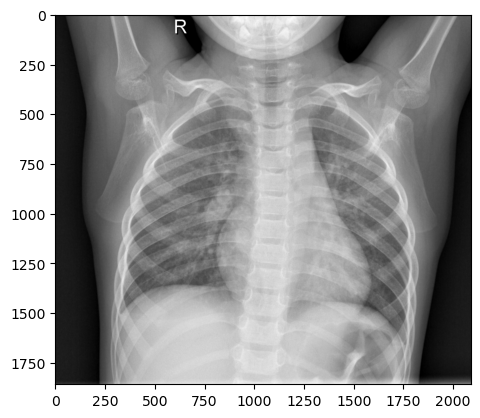

In [24]:
normal_lung_image = load_img("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg")
print("NORMAL")
plt.imshow(normal_lung_image)
plt.show()

PNEUMONIA


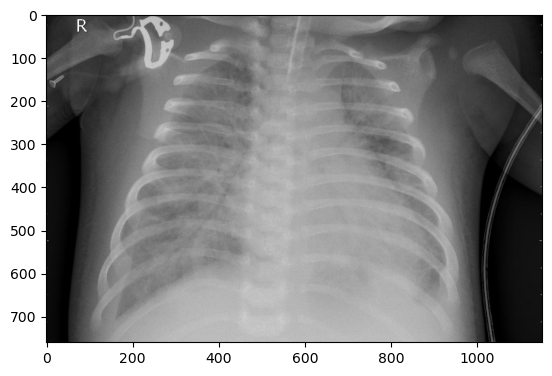

In [25]:
normal_lung_image = load_img("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg")
print("PNEUMONIA")
plt.imshow(normal_lung_image)
plt.show()

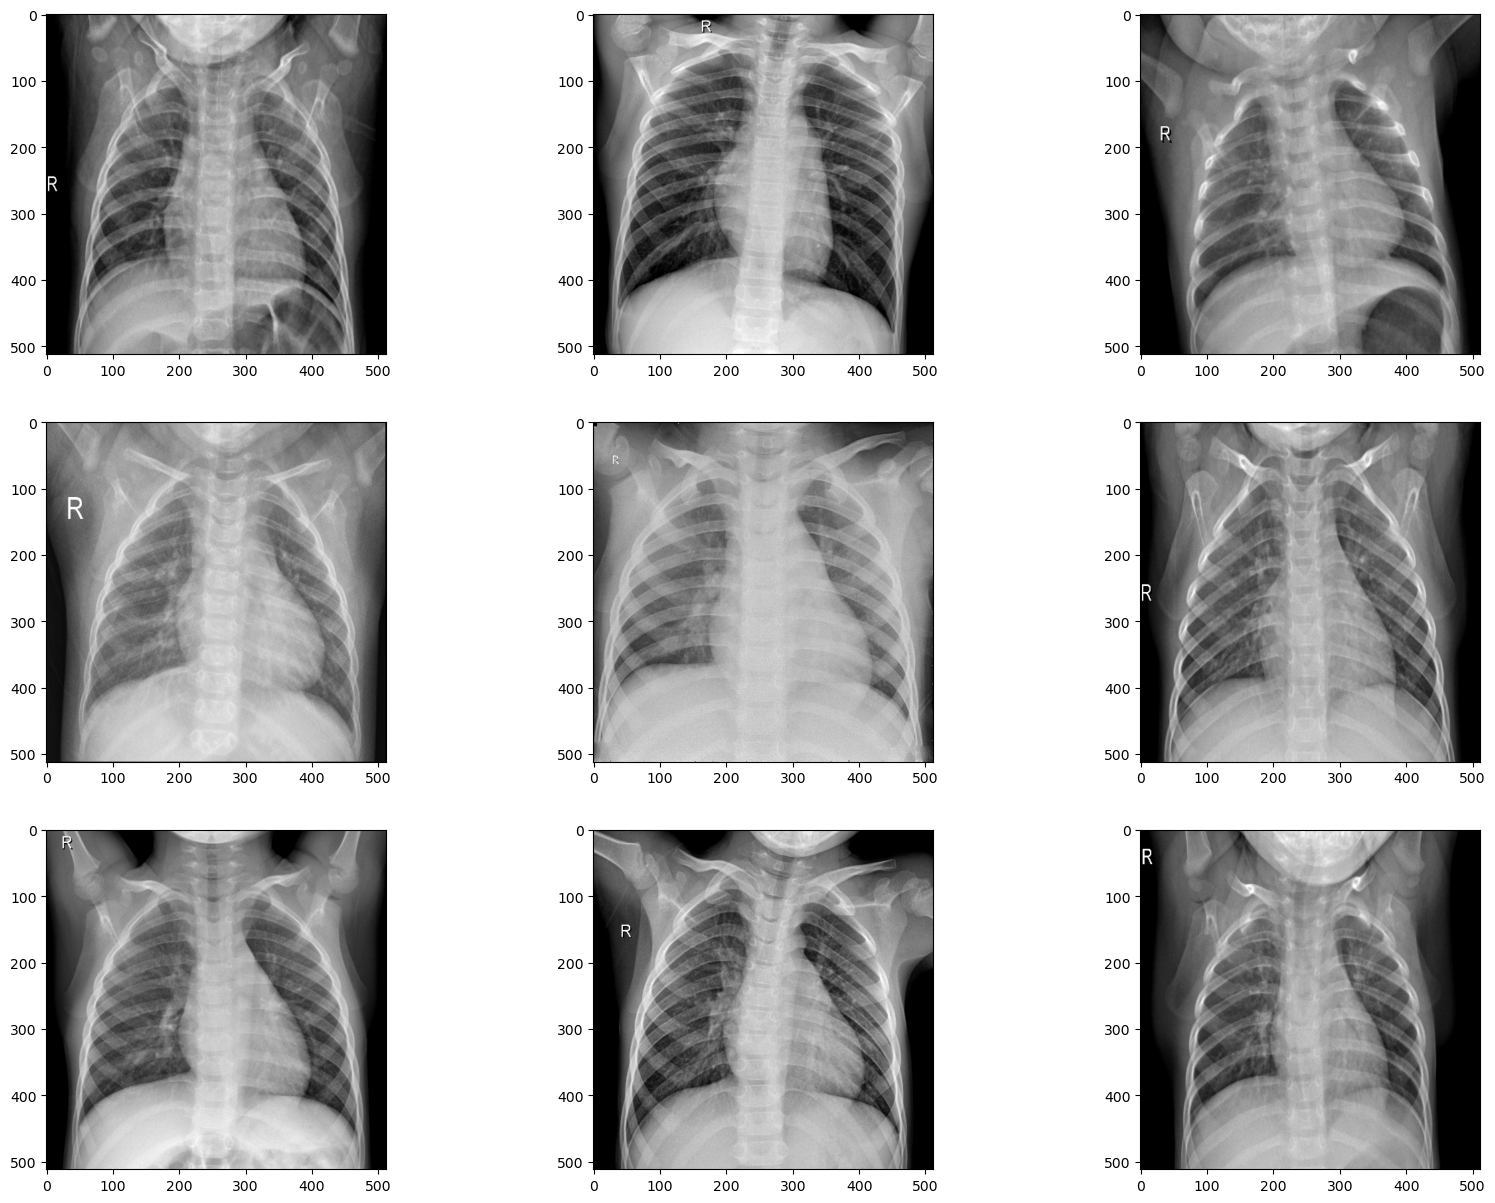

In [26]:
fig = plt.figure(figsize = (20, 15))
columns, rows = 3, 3
for i in range(1, 10):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)

#### <span style='background:#4A1810;color:#ffffff;'> Image erosion </span>

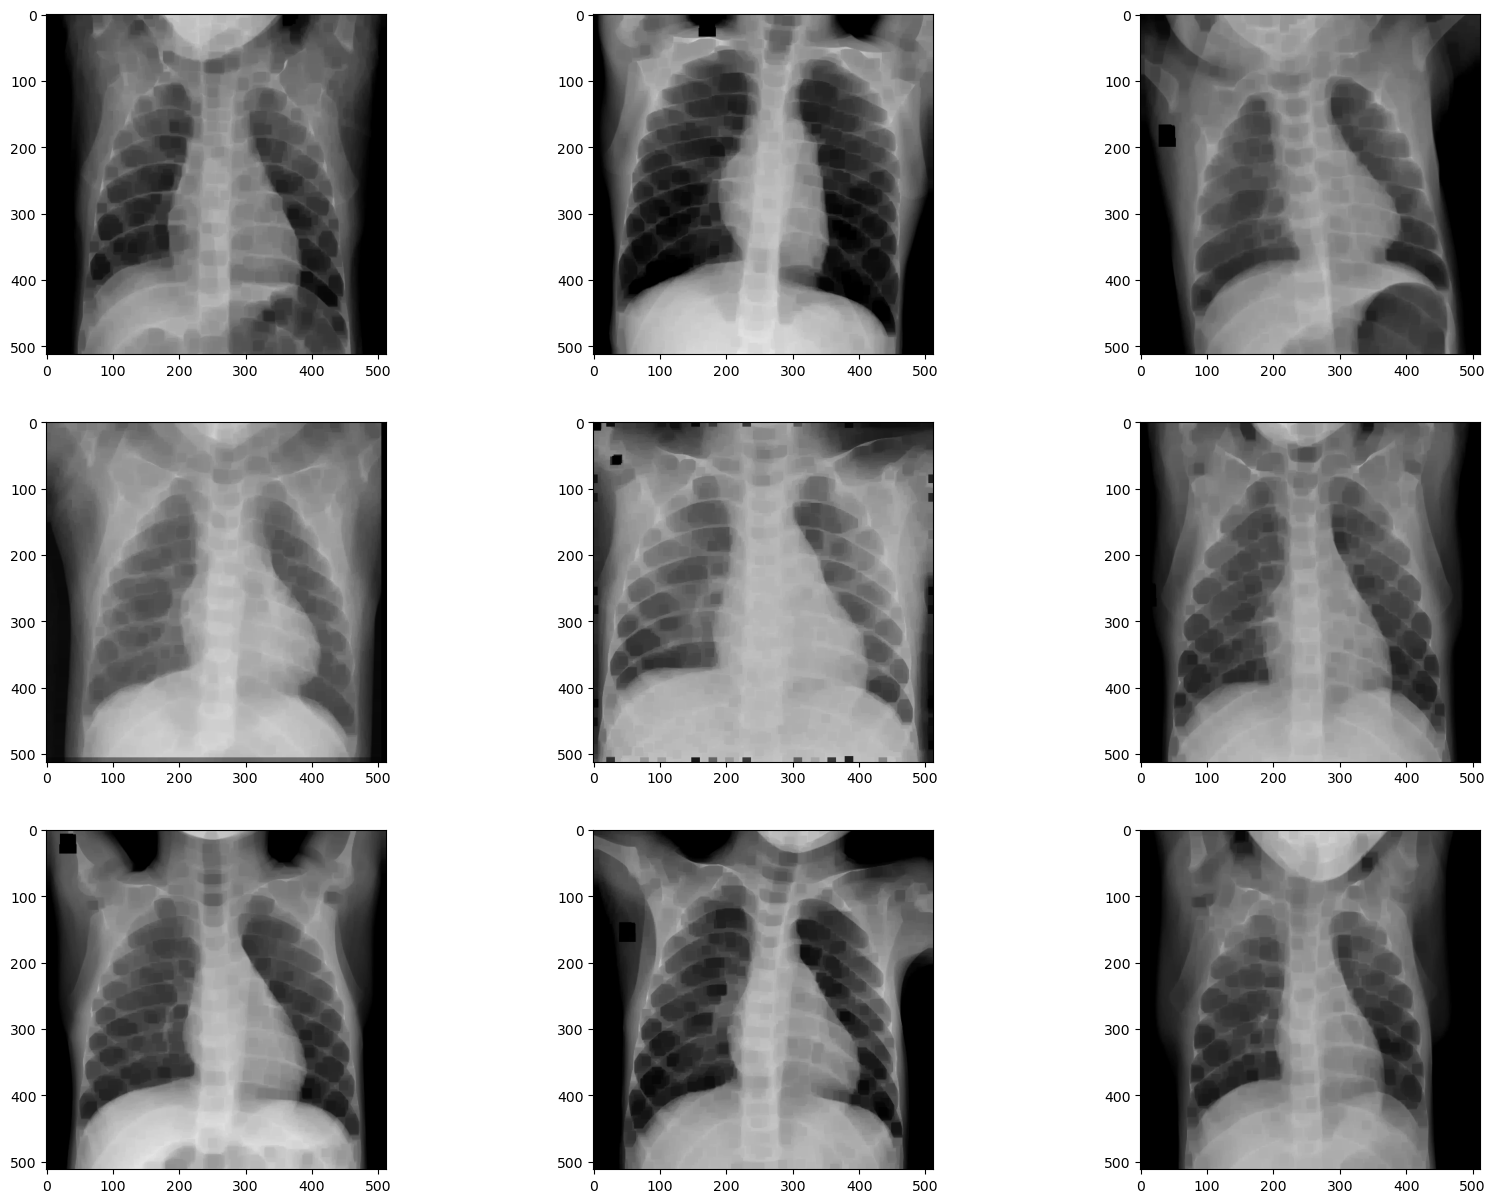

In [28]:
fig = plt.figure(figsize = (20, 15))
columns, rows = 3, 3
for i in range(1, 10):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    kernel = np.ones((5, 5), np.uint8)
    image_erosion = cv2.erode(img, kernel, iterations=3)
    fig.add_subplot(rows, columns, i)
    plt.imshow(image_erosion)

#### <span style='background:#4A1810;color:#ffffff;'> Image dilation </span>

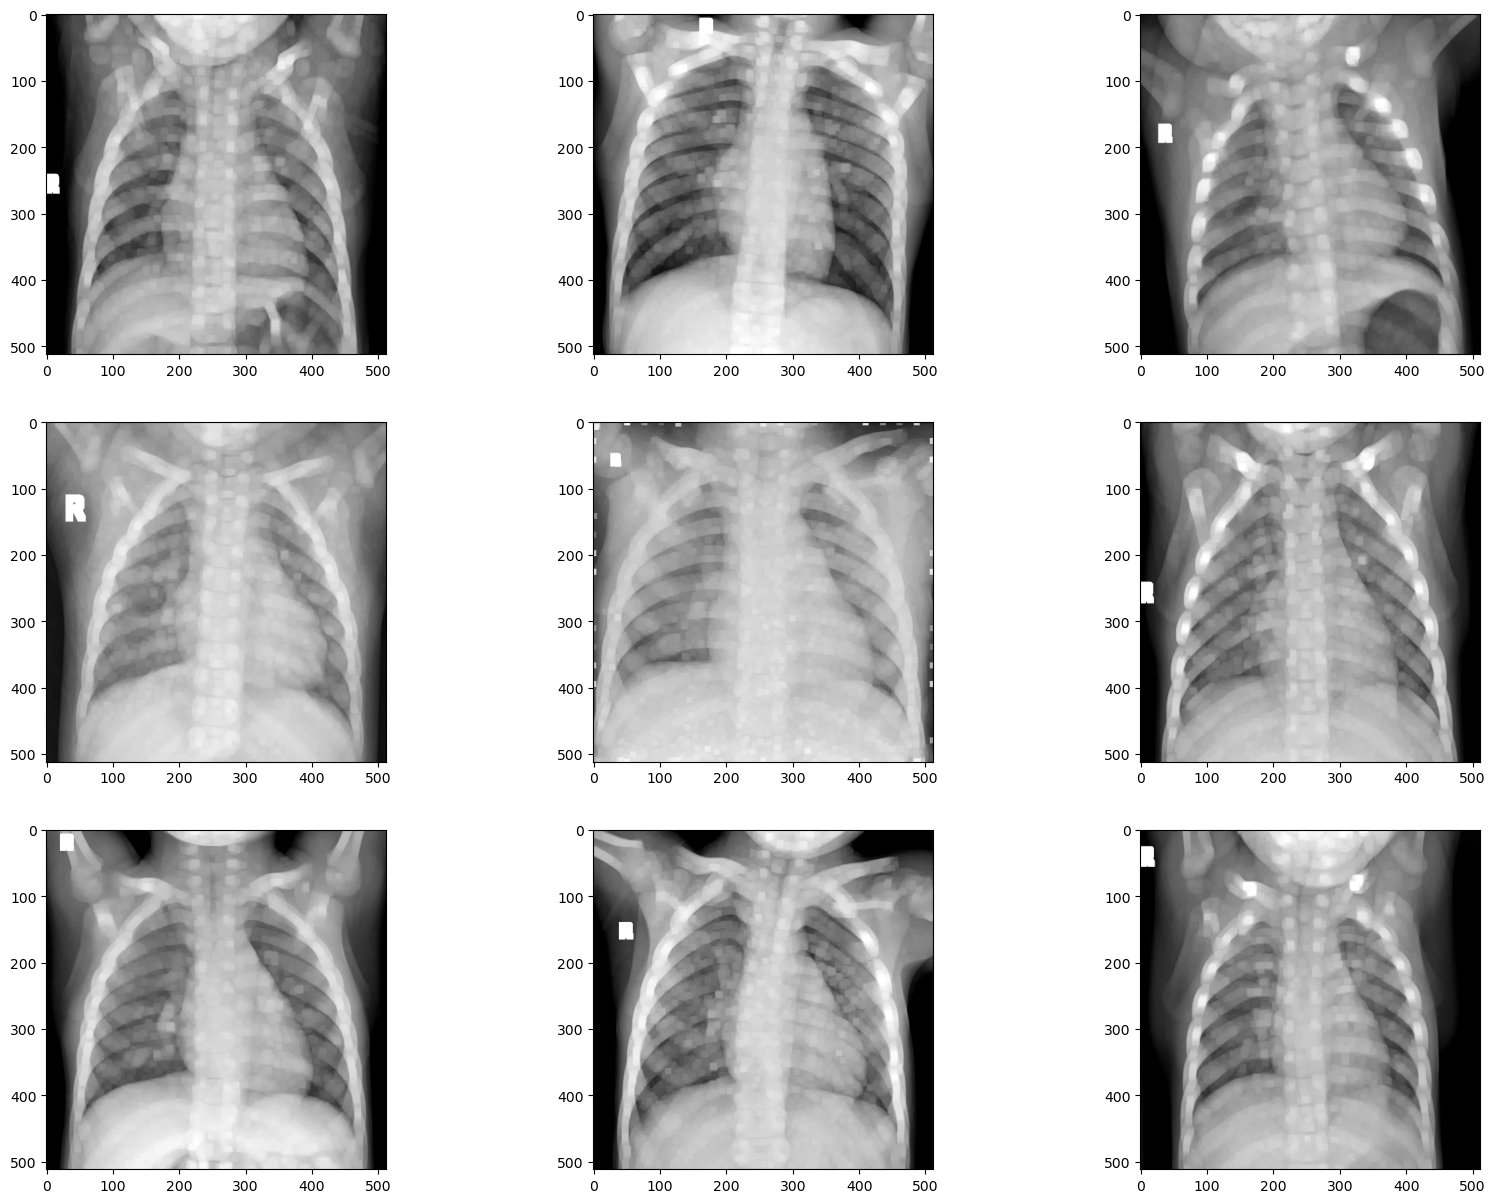

In [29]:
fig = plt.figure(figsize = (20, 15))
columns, rows = 3, 3

for i in range(1, 10):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    kernel = np.ones((5, 5), np.uint8)
    image_dilation = cv2.dilate(img, kernel, iterations = 2)
    fig.add_subplot(rows, columns, i)
    plt.imshow(image_dilation)

#### <span style='background:#4A1810;color:#ffffff;'> Convert the images to greyscale and then apply Gaussian blur to them </span>

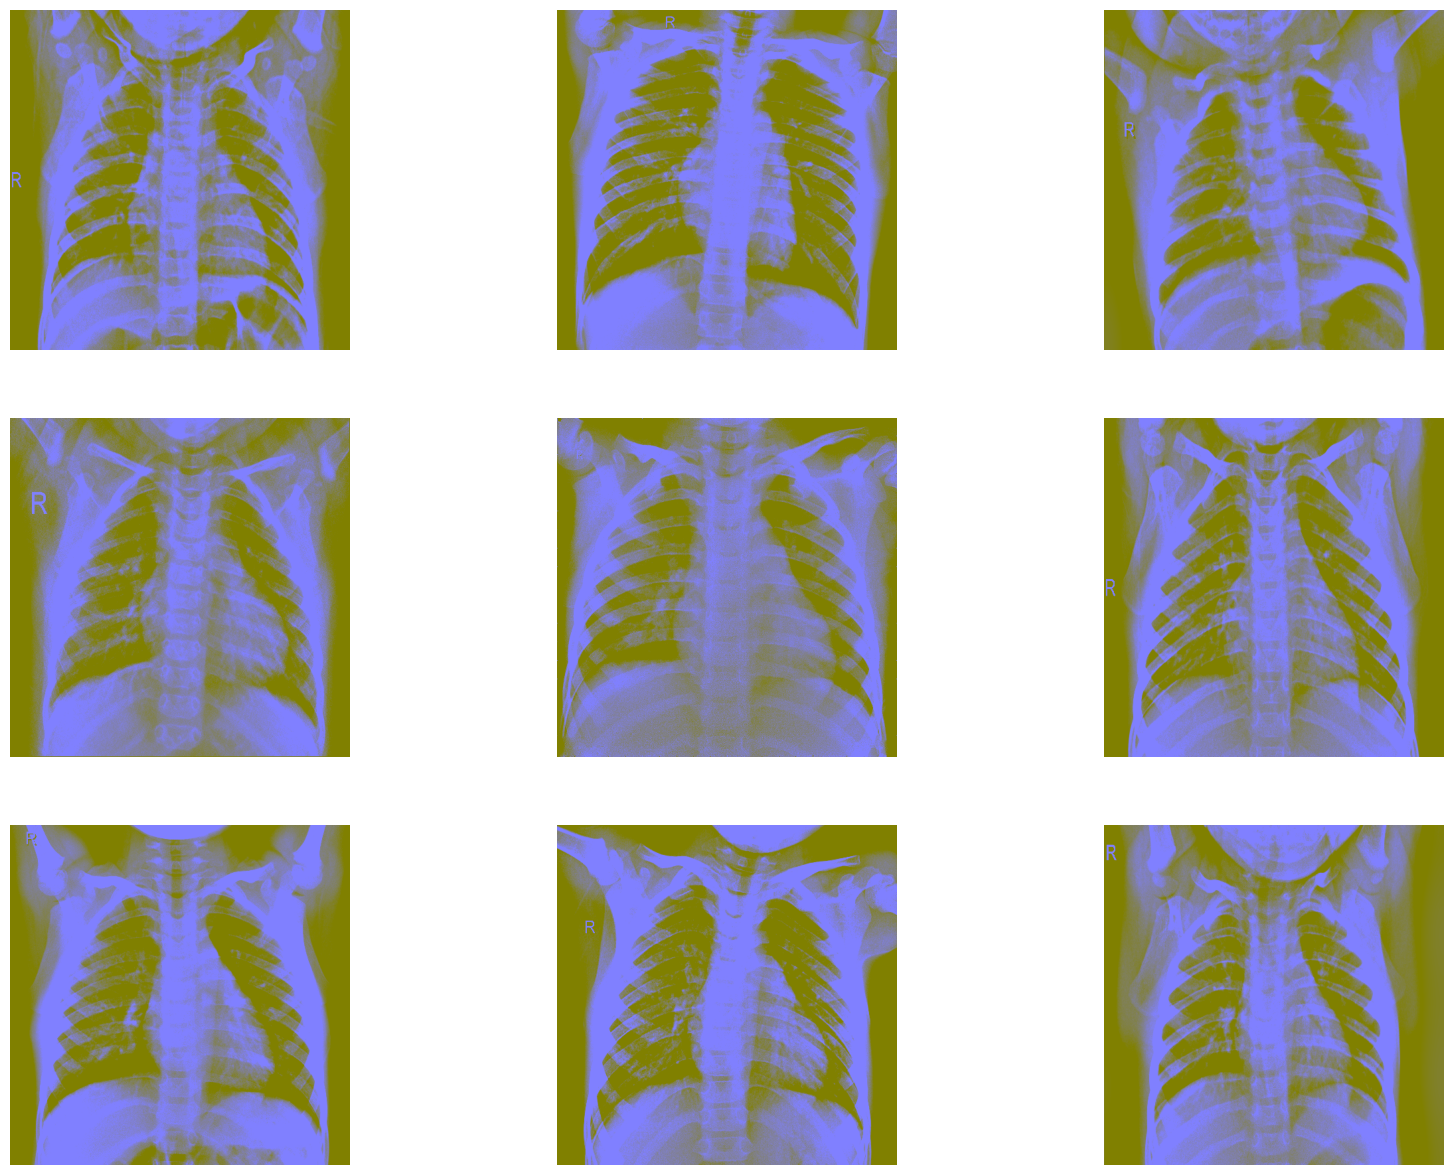

In [30]:
fig = plt.figure(figsize = (20, 15))
columns, rows = 3, 3

for i in range(1, 10):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img = cv2.addWeighted (img, 4, cv2.GaussianBlur(img, (0, 0), 512/10), -4, 128)
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
    plt.axis(False)

#### <span style='background:#4A1810;color:#ffffff;'> Canny edge detection: </span>

<mark>Canny edge detection is a technique to extract useful structural information from different vision objects and dramatically reduce the amount of data to be processed. It has been widely applied in various computer vision systems</mark>

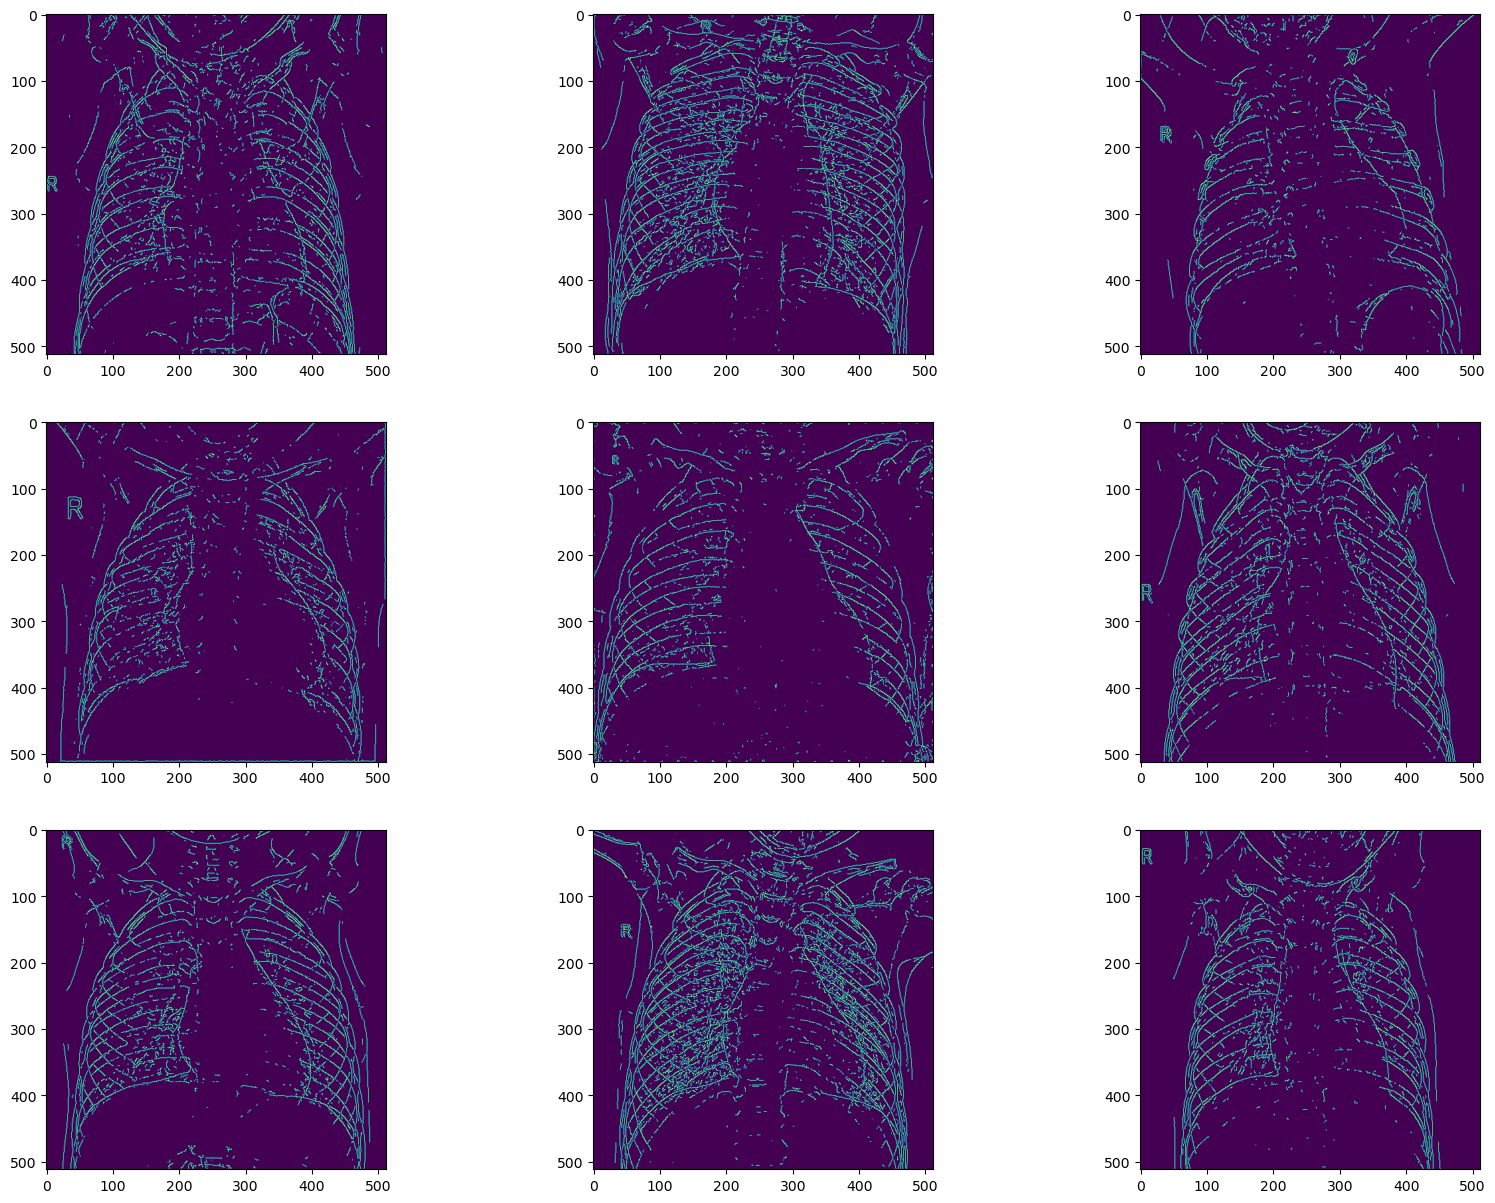

In [31]:
fig = plt.figure(figsize = (20, 15))
columns, rows = 3, 3

for i in range(1, 10):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detected_edges = cv2.Canny(img, 80, 100)
    fig.add_subplot(rows, columns, i)
    plt.imshow(detected_edges)

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Build deep learning models 🔺️</p>

In [32]:
train_dir = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/train"
test_dir = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test"
validation_dir = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/val"

In [33]:
%%time

train_datagen = ImageDataGenerator(
            rescale = 1/255.,
            horizontal_flip = True,
            vertical_flip = True,
            rotation_range = 0.3,
            zca_whitening = True,
            width_shift_range = 0.25,
            height_shift_range = 0.25,
            channel_shift_range = 0.35,
            shear_range = 0.2,
            zoom_range = 0.4)

val_test_datagen = ImageDataGenerator(rescale = 1./255)

train_set = train_datagen.flow_from_directory(train_dir, class_mode = "binary", batch_size = 16, target_size = (224, 224))
validation_set = val_test_datagen.flow_from_directory(validation_dir, class_mode = "binary", batch_size = 16, target_size = (224, 224))
test_set = val_test_datagen.flow_from_directory(test_dir, class_mode = "binary", batch_size = 16, target_size = (224, 224))

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
CPU times: total: 156 ms
Wall time: 133 ms


#### <span style='background:#4A1810;color:#ffffff;'> Cache and prefetch data </span>


If we use <mark>flow_from_directory along with ImageDataGenerator()</mark> to set up the dataset, it will not be compatible with <mark>tensorflow.data.AUTOTUNE.</mark> Use <mark>tensorflow.keras.preprocessing.image_dataset_from_directory</mark> instead to load the dataset.

In [34]:
'''
AUTOTUNE = tensorflow.data.experimental.AUTOTUNE

train_set = train_set.cache().prefetch(buffer_size = AUTOTUNE)
test_set = test_set.cache().prefetch(buffer_size = AUTOTUNE)
validation_set = validation_set.cache().prefetch(buffer_size = AUTOTUNE)
'''
pass

#### <span style='background:#4A1810;color:#ffffff;'> Build CNN model 🔺️ </span>

## What is a convolutional neural network algorithm?

A convolutional neural network (ConvNet / Convolutional neural networks -CNN) is a deep learning algorithm that can take an input image and separate various aspects/objects in the image. CNN is a network architecture for deep learning that learns directly from data. CNNs are particularly useful for finding patterns in images to recognize objects, classes, and categories. They can also be quite effective for classifying audio, time-series and signal data.

![](https://miro.medium.com/max/1400/1*uAeANQIOQPqWZnnuH-VEyw.jpeg)


## Convolution layer

A convolutional layer is the main building block of a CNN. It contains a set of filters (or kernels) whose parameters will be learned throughout the training. The size of the filters is usually smaller than the actual image. Each filter intertwines with the image and creates an activation map.

![](https://miro.medium.com/max/1400/1*D6iRfzDkz-sEzyjYoVZ73w.gif)


## Convolutional stride

Stride is a parameter of the neural network's filter that modifies the amount of movement over the image or video.

![](https://csdl-images.ieeecomputer.org/trans/si/2020/04/figures/ko1ab-2961602.gif)


## Convolutional padding

Padding is a term relevant to convolutional neural networks as it refers to the amount of pixels added to an image when it is being processed by the kernel of a CNN. For example, if the padding in a CNN is set to zero, then every pixel value that is added will be of value zero.

What does padding ='same' means? In this case, we add 'p' padding layers such that the output image has the same dimensions as the input image. It is called "same" because the output size is the same as the input size (when stride = 1). Using 'same' ensures that the filter is applied to all the elements of the input. Normally, padding is set to "SAME" while training the model.

![](https://miro.medium.com/max/2000/1*WpOcRWlofm0Z0EDUTKefzg.gif)


## Pooling layer

The purpose of the pooling layers is to reduce the dimensions of the hidden layer by combining the outputs of neuron clusters at the previous layer into a single neuron in the next layer.

![](https://nico-curti.github.io/NumPyNet/NumPyNet/images/maxpool.gif)

![](https://miro.medium.com/max/1400/1*fXxDBsJ96FKEtMOa9vNgjA.gif)

In [35]:
model1 = Sequential()

#convolutional neural networks - CNNs
model1.add(Conv2D(32, (3,3), strides = (1, 1),activation = "relu", padding = "same", input_shape = (224, 224, 3)))
model1.add(MaxPooling2D(pool_size = (2, 2)))
model1.add(Conv2D(64, (3,3), strides = (1, 1), padding = "same", activation = "relu"))
model1.add(MaxPooling2D(pool_size = (2, 2)))
model1.add(Dropout(0.2))
model1.add(Conv2D(128, (3,3), strides = (1, 1), padding = "same", activation = "relu"))
model1.add(MaxPooling2D(pool_size = (2, 2)))
model1.add(Conv2D(256, (3,3), strides = (1, 1), padding = "same", activation = "relu"))
model1.add(MaxPooling2D(pool_size = (2, 2)))
model1.add(Dropout(0.2))
model1.add(Flatten())

#fully connected layer
model1.add(Dense(128, activation = "relu"))
model1.add(Dense(64, activation = "relu"))
model1.add(Dense(32, activation = "relu"))
model1.add(Dense(1, activation = "sigmoid"))
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,821,441 (26.02 MB)

 Trainable params: 6,821,441 (26.02 MB)

 Non-trainable params: 0 (0.00 B)

#### <span style='background:#4A1810;color:#ffffff;'> Compile the model </span>

In [36]:
model1.compile(optimizer = "rmsprop", loss = "binary_crossentropy", metrics = ["accuracy"])

#### <span style='background:#4A1810;color:#ffffff;'> Train the model </span>

In [37]:
%%time

early_stopping_callbacks = tensorflow.keras.callbacks.EarlyStopping(patience = 15,
                                                                    restore_best_weights = True,
                                                                    verbose = 1)

CPU times: total: 0 ns
Wall time: 0 ns


In [39]:
%%time

history = model1.fit(
    train_set,
    epochs=20,
    validation_data=validation_set,
    steps_per_epoch=100,
    callbacks=[early_stopping_callbacks]
)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 450ms/step - accuracy: 0.7311 - loss: 0.7954 - val_accuracy: 0.5000 - val_loss: 0.8263
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 395ms/step - accuracy: 0.7366 - loss: 0.4551 - val_accuracy: 0.6875 - val_loss: 0.5425
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 377ms/step - accuracy: 0.8236 - loss: 0.4193 - val_accuracy: 0.7500 - val_loss: 0.4648
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8229 - loss: 0.3462 - val_accuracy: 0.6875 - val_loss: 0.7555
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 343ms/step - accuracy: 0.8391 - loss: 0.3651 - val_accuracy: 0.6250 - val_loss: 0.8191
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 329ms/step - accuracy: 0.8475 - loss: 0.3462 - val_accuracy: 0.6250 - val_loss: 0.6740
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 327ms/step - accuracy: 0.8300 - loss: 0.3640 - val_accuracy: 0.7500 - val_loss: 0.4654
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8710 - loss: 0.317

In [ ]:
model1.input, model1.output

AttributeError: The layer sequential has never been called and thus has no defined input.

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Visualize the performance of model1</p>

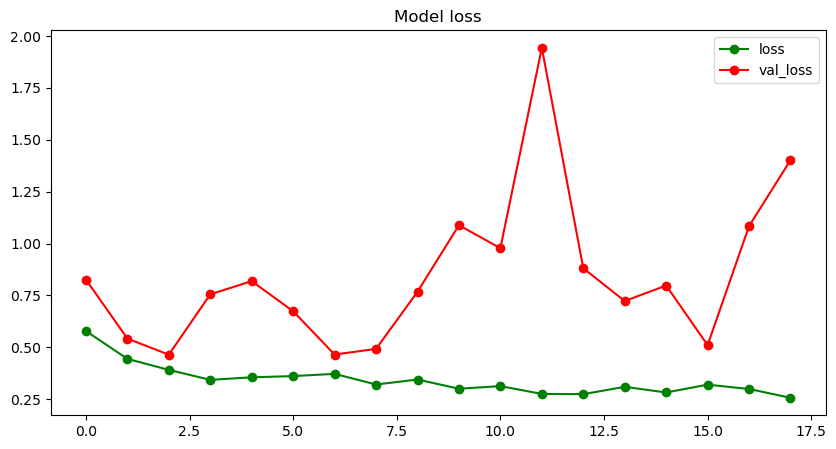

In [45]:
plt.figure(figsize = (10, 5))
plt.title("Model loss")
plt.plot(history.history["loss"], "go-")
plt.plot(history.history["val_loss"], "ro-")
plt.legend(["loss", "val_loss"])
plt.show()

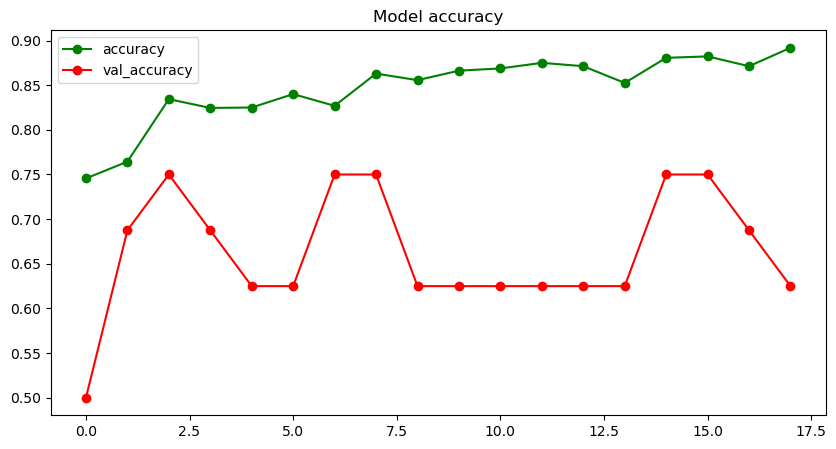

In [46]:
plt.figure(figsize = (10, 5))
plt.title("Model accuracy")

plt.plot(history.history["accuracy"], "go-")
plt.plot(history.history["val_accuracy"], "ro-")
plt.legend(["accuracy", "val_accuracy"])
plt.show()

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Evaluate model1 on the test set </p>

In [47]:
#scores = model1.evaluate_generator(test_set)
#print("\n%s: %.3f%%" % (model1.metrics_names[0], scores[0]*100))
#print("\n%s: %.3f%%" % (model1.metrics_names[1], scores[1]*100))

test_loss, test_accuracy = model1.evaluate(test_set, steps = 50)
print("The testing accuracy is: ", test_accuracy * 100, "%")
print("The testing loss is: ", test_loss * 100, "%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.8195 - loss: 0.4661
The testing accuracy is:  82.05128312110901 %
The testing loss is:  47.00162708759308 %


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">TRANSFER LEARNING</p>

![](https://slideplayer.com/slide/15398015/93/images/5/Transfer+Learning.jpg)

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">VGG16 model</p>

In [48]:
base_model1 = VGG16(include_top = False, weights = "imagenet", input_shape = (224, 224, 3), pooling = "max",
                    classes = 2)

#base_model1.load_weights("../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5")
base_model1.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model2 = Sequential()
model2.add(base_model1)
model2.add(Flatten())

model2.add(Dense(128, activation = "relu"))
model2.add(Dense(64, activation = "relu"))
model2.add(Dense(32, activation = "relu"))
model2.add(Dense(1, activation = "sigmoid"))

# freeze the layers
for layer in base_model1.layers:
    layer.trainable = False

model2.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [51]:
%%time

history = model2.fit(train_set, epochs = 20, validation_data = validation_set, steps_per_epoch = 100,
                               callbacks = [early_stopping_callbacks])

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 668ms/step - accuracy: 0.7745 - loss: 0.4828 - val_accuracy: 0.8125 - val_loss: 0.4287
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 678ms/step - accuracy: 0.8637 - loss: 0.3043 - val_accuracy: 0.7500 - val_loss: 0.5723
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 691ms/step - accuracy: 0.8727 - loss: 0.2861 - val_accuracy: 0.7500 - val_loss: 0.7383
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.8798 - loss: 0.2795 - val_accuracy: 0.7500 - val_loss: 0.5837
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 67s 668ms/step - accuracy: 0.8813 - loss: 0.2722 - val_accuracy: 0.7500 - val_loss: 0.6242
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 680ms/step - accuracy: 0.8681 - loss: 0.2792 - val_accuracy: 0.6875 - val_loss: 0.4623
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - accuracy: 0.8988 - loss: 0.2531 - val_accuracy: 0.7500 - val_loss: 0.6608
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.9068 - loss: 0

### Visualize the performance of model2

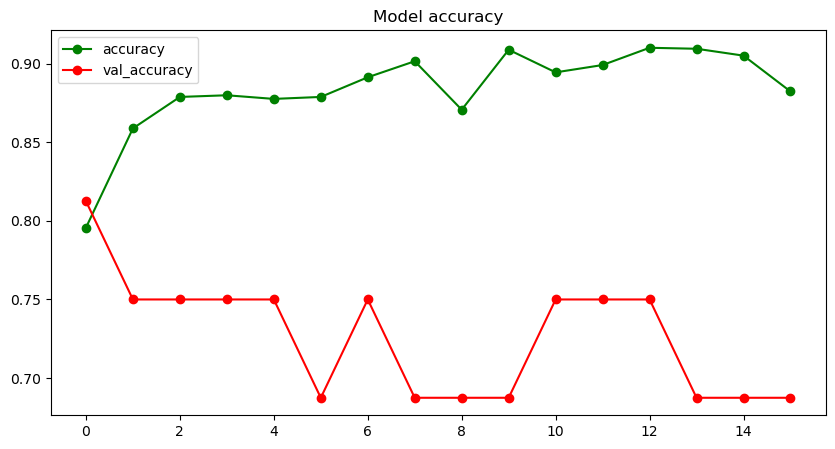

In [52]:
plt.figure(figsize = (10, 5))
plt.title("Model accuracy")
plt.plot(history.history["accuracy"], "go-")
plt.plot(history.history["val_accuracy"], "ro-")
plt.legend(["accuracy", "val_accuracy"])
plt.show()

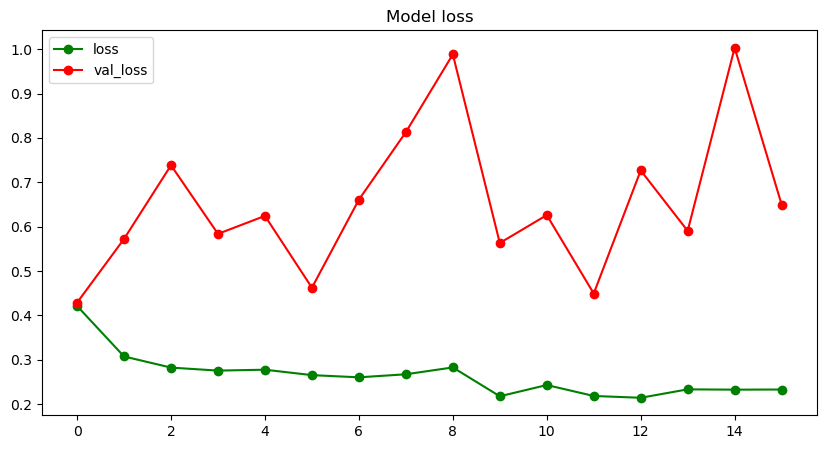

In [53]:
plt.figure(figsize = (10, 5))
plt.title("Model loss")
plt.plot(history.history["loss"], "go-")
plt.plot(history.history["val_loss"], "ro-")
plt.legend(["loss", "val_loss"])
plt.show()

### Evaluate model2 on the test set

In [54]:
#scores = model1.evaluate_generator(test_set)
#print("\n%s: %.3f%%" % (model1.metrics_names[0], scores[0]*100))
#print("\n%s: %.3f%%" % (model1.metrics_names[1], scores[1]*100))

test_loss, test_accuracy = model2.evaluate(test_set, steps = 50)
print("The testing accuracy is: ", test_accuracy * 100, "%")
print("The testing loss is: ", test_loss * 100, "%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 553ms/step - accuracy: 0.6698 - loss: 0.5996
The testing accuracy is:  67.78846383094788 %
The testing loss is:  59.26249623298645 %


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">ResNet50V2 model</p>

In [ ]:
base_model2 = tensorflow.keras.applications.ResNet50V2(weights = "imagenet",
                                                       input_shape = (224, 224, 3),
                                                       pooling = "max", include_top = False,
                                                       classes = 2)

for layer in base_model2.layers:
    layer.trainable = False
    
#base_model2.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [56]:
model3 = Sequential()
model3.add(base_model2)
model3.add(Flatten())

model3.add(Dense(128, activation = "relu"))
model3.add(Dense(64, activation = "relu"))
model3.add(Dense(32, activation = "relu"))
model3.add(Dense(1, activation = "sigmoid"))

# freeze the layers
for layer in base_model2.layers:
    layer.trainable = False

model3.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [57]:
%%time

history = model3.fit(train_set, epochs = 20, validation_data = validation_set, steps_per_epoch = 100,
                              callbacks = [early_stopping_callbacks])

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 335ms/step - accuracy: 0.7808 - loss: 0.7139 - val_accuracy: 0.9375 - val_loss: 0.2645
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 331ms/step - accuracy: 0.9108 - loss: 0.2357 - val_accuracy: 0.8750 - val_loss: 0.3744
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.9071 - loss: 0.2151 - val_accuracy: 0.8750 - val_loss: 0.2601
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8998 - loss: 0.2063 - val_accuracy: 0.8125 - val_loss: 0.5502
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 327ms/step - accuracy: 0.9153 - loss: 0.2266 - val_accuracy: 0.8750 - val_loss: 0.3473
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - accuracy: 0.9156 - loss: 0.1805 - val_accuracy: 0.9375 - val_loss: 0.2797
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 322ms/step - accuracy: 0.9148 - loss: 0.2230 - val_accuracy: 0.9375 - val_loss: 0.2881
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9304 - loss: 0.167

### Visualize performance of model3

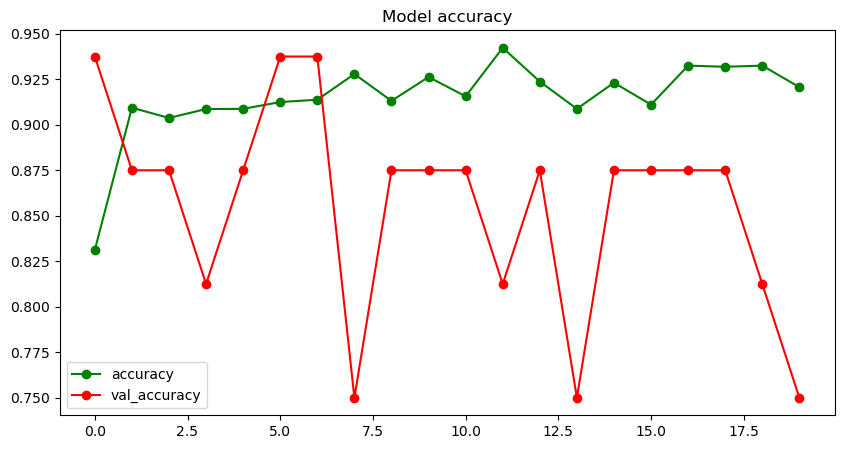

In [58]:
plt.figure(figsize = (10, 5))
plt.title("Model accuracy")
plt.plot(history.history["accuracy"], "go-")
plt.plot(history.history["val_accuracy"], "ro-")
plt.legend(["accuracy", "val_accuracy"])
plt.show()

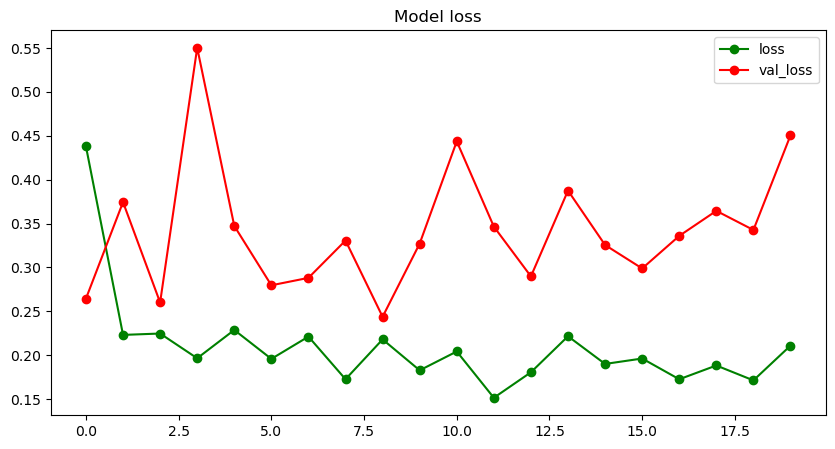

In [59]:
plt.figure(figsize = (10, 5))
plt.title("Model loss")
plt.plot(history.history["loss"], "go-")
plt.plot(history.history["val_loss"], "ro-")
plt.legend(["loss", "val_loss"])
plt.show()

### Evaluate model3 on the test set

In [60]:
#scores = model1.evaluate_generator(test_set)
#print("\n%s: %.3f%%" % (model1.metrics_names[0], scores[0]*100))
#print("\n%s: %.3f%%" % (model1.metrics_names[1], scores[1]*100))

test_loss, test_accuracy = model3.evaluate(test_set, steps = 50)
print("The testing accuracy is: ", test_accuracy * 100, "%")
print("The testing loss is: ", test_loss * 100, "%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.8765 - loss: 0.3000
The testing accuracy is:  87.17948794364929 %
The testing loss is:  30.533838272094727 %


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4A1810; font-family:sans-serif;color:#FFFFFF;font-size:130%;text-align:center;border-radius:55px 1px;">Prediction of a new image </p>

In [ ]:
%%time

new_image_path = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test/PNEUMONIA/person142_bacteria_682.jpeg"
test_image = image.load_img(new_image_path, target_size = (224, 224))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
#test_image = np.reshape(test_image, (1, 224, 224, 3))
test_image = test_image / 255

#___________________________________________________________________

result = model3.predict(test_image)
train_set.class_indices
if result[0][0] == 0:
    prediction = "N O R M A L"
else:
    prediction = "P N E U M O N I A"

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
P N E U M O N I A
CPU times: total: 1.27 s
Wall time: 1.02 s


### Save the model to disk

In [62]:
model3.save("pneumonia_detection_model_vgg16_resnet50v2.h5")
print(colored("Model3 was succesfully saved to disk...", color = "green", attrs = ["bold", "dark"]))

Model3 was succesfully saved to disk...


### Some time later you may need that model to use

In [3]:
import tensorflow

model_loaded = tensorflow.keras.models.load_model("../../../ai-microclinic-offline-dataset/chest_xray/pneumonia_detection_model_vgg16_resnet50v2.h5")
model_loaded.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,837,443 (90.93 MB)

 Trainable params: 272,641 (1.04 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

 Optimizer params: 2 (12.00 B)

### Use loaded model to predict new image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
This image is 79.231 percent PNEUMONIA


C:\Users\karti\AppData\Local\Temp\ipykernel_20880\2521547434.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("This image is %.3f percent %s"% (statistic, "PNEUMONIA"))


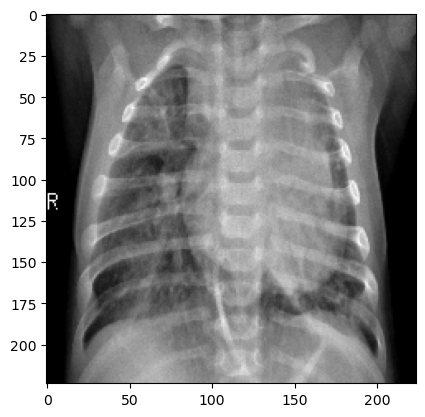

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def image_prediction(new_image_path):
    test_image = image.load_img(new_image_path, target_size = (224, 224))
    test_image = image.img_to_array(test_image)
    #test_image = np.reshape(test_image, (224, 224, 3))
    test_image = np.expand_dims(test_image, axis = 0)
    test_image = test_image / 255.0
    model_loaded = tensorflow.keras.models.load_model("../../../ai-microclinic-offline-dataset/chest_xray/pneumonia_detection_model_vgg16_resnet50v2.h5")
    prediction = model_loaded.predict(test_image)
    test_image_for_plotting = image.load_img(new_image_path, target_size = (224, 224))
    plt.imshow(test_image_for_plotting)
    if(prediction[0] > 0.5):
        statistic = prediction[0] * 100 
        print("This image is %.3f percent %s"% (statistic, "PNEUMONIA"))
    else:
        statistic = (1.0 - prediction[0]) * 100
        print("This image is %.3f percent %s" % (statistic, "NORMAL"))
     
 
# call and use the function
image_prediction("../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg")

### Get test data and test labels

In [65]:
test_dir = "../../../ai-microclinic-offline-dataset/chest_xray/chest_xray/test"
test_data, test_labels = [], []

In [66]:
for i in ["/NORMAL/", "/PNEUMONIA/"]:
    for image in (os.listdir(test_dir + i)):
        image = plt.imread(test_dir + i + image)
        image = cv2.resize(image, (224, 224))
        image = np.dstack([image, image, image])
        image = image.astype("float32") / 255
        if i == "/NORMAL/":
            label = 0
        elif i == "/PNEUMONIA/":
            label = 1
        test_data.append(image)
        test_labels.append(label)

test_data = np.array(test_data)
test_labels = np.array(test_labels)

### Plot confusion matrix

_______C o n f u s i o n   m a t r i x_______

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step


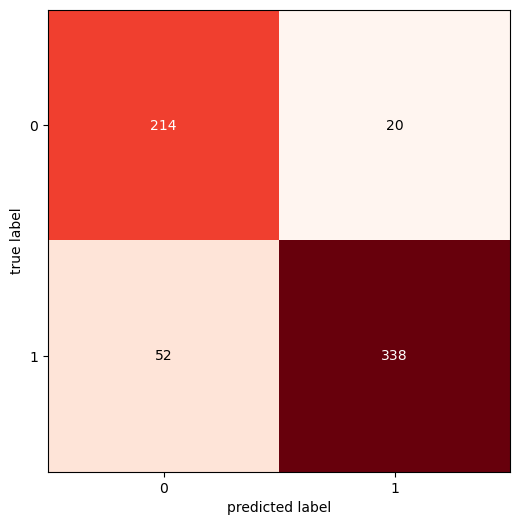

In [67]:
print("_______C o n f u s i o n   m a t r i x_______\n")

predictions = model_loaded.predict(test_data)
conf_m = confusion_matrix(test_labels, np.round(predictions))
acc = accuracy_score(test_labels, np.round(predictions)) * 100
tn, fp, fn, tp = conf_m.ravel()

fig, ax = plot_confusion_matrix(conf_mat = conf_m, figsize = (6, 6), cmap = matplotlib.pyplot.cm.Reds)
plt.show()

### Get test metrics

In [68]:
%%time

precision = tp / (tp + fp) * 100
recall = tp / (tp + fn) * 100
print("Accuracy: {}%".format(acc))
print("Precision: {}%".format(precision))
print("Recall: {}%".format(recall))
print("F1-score: {}".format(2 * precision * recall / (precision + recall)))   

Accuracy: 88.46153846153845%
Precision: 94.41340782122904%
Recall: 86.66666666666667%
F1-score: 90.37433155080213
CPU times: total: 0 ns
Wall time: 1.39 ms


## Let's display correct and incorrect predicted classes

In [69]:
predictions = list()
preds = model_loaded.predict(test_data)
for i in preds:
    if i >= 0.5:
        predictions.append(1)
    else:
        predictions.append(0)
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

<mark>np.nonzero() function is used to compute the indices of the elements that are non-zero. <\mark> 

In [70]:
correct_predictions = np.nonzero(predictions == test_labels)[0]
incorrect_predictions = np.nonzero(predictions != test_labels)[0]

# let's look at indices of correct predictions
print("Indices of correct predictions:\n", correct_predictions[:15])

# let's look at indices of incorrect correct predictions
print("\nIndices of incorrect predictions:\n", incorrect_predictions[:15])

Indices of correct predictions:
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]

Indices of incorrect predictions:
 [ 45  67  94  95  98 119 121 122 126 129 131 132 133 134 140]


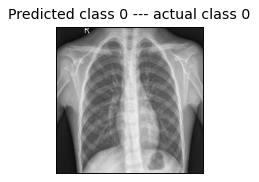

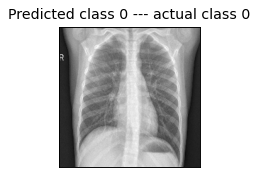

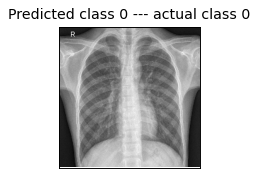

In [71]:
# display correct predictions

i = 0
for a in correct_predictions[:3]:
    plt.figure(figsize = (8, 6), dpi = 85)
    plt.subplot(3, 1, i + 1)
    plt.xticks([]), plt.yticks([])
    plt.imshow(test_data[a].reshape(224, 224, 3))
    plt.title("Predicted class {} --- actual class {}".format(predictions[a], test_labels[a]))
    plt.tight_layout()
    i += 1

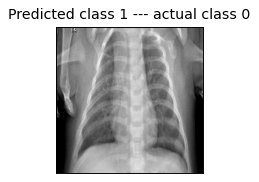

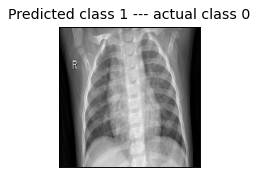

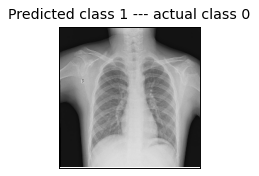

In [72]:
# display incorrect predictions

i = 0
for a in incorrect_predictions[:3]:
    plt.figure(figsize = (8, 6), dpi = 85)
    plt.subplot(3, 1, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_data[a].reshape(224, 224, 3))
    plt.title("Predicted class {} --- actual class {}".format(predictions[a], test_labels[a]))
    plt.tight_layout()
    i += 1

# Reference for pictures and animations



https://medium.datadriveninvestor.com/convolutional-neural-networks-3b241a5da51e

https://www.computer.org/csdl/journal/si/2020/04/08957307/1ilQS7GE9MY

https://towardsdatascience.com/what-is-transposed-convolutional-layer-40e5e6e31c11

https://nico-curti.github.io/NumPyNet/NumPyNet/layers/maxpool_layer.html

https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53


# Thank you all for reading my notebook! 🤗

In [1]:
#Convert .h5 to .tflite
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("pneumonia_detection_model_vgg16_resnet50v2.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("../../android/app/src/main/assets/pneumonia_detection_model_vgg16_resnet50v2.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted and saved as pneumonia_detection_model_vgg16_resnet50v2.tflite")


INFO:tensorflow:Assets written to: C:\Users\karti\AppData\Local\Temp\tmptv5tvch1\assets


INFO:tensorflow:Assets written to: C:\Users\karti\AppData\Local\Temp\tmptv5tvch1\assets


Saved artifact at 'C:\Users\karti\AppData\Local\Temp\tmptv5tvch1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1311517614800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517616720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517616144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517617296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517614992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517614608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517615184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517618256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517618448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311517617104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1311

In [2]:
import tensorflow as tf
interpreter = tf.lite.Interpreter(model_path="../../android/app/src/main/assets/pneumonia_detection_model_vgg16_resnet50v2.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("Input shape:", input_details[0]['shape'])
print("Output shape:", output_details[0]['shape'])


Input shape: [  1 224 224   3]
Output shape: [1 1]


c:\Users\karti\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
